# Image Augmentation  

## 1) Import e setup

In [ ]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [ ]:
def show_images(tensor_images, nrow=8, title=None):
    """Mostra una griglia di immagini (tensor in [C,H,W] oppure batch [B,C,H,W])."""
    if tensor_images.dim() == 3:
        tensor_images = tensor_images.unsqueeze(0)
    grid = make_grid(tensor_images, nrow=nrow, padding=2)
    # grid: [C,H,W] -> [H,W,C]
    img = grid.permute(1, 2, 0).cpu().numpy()
    plt.figure(figsize=(10, 5))
    plt.imshow(img)
    plt.axis("off")
    if title:
        plt.title(title)
    plt.show()

## 2) Caricamento di CIFAR-10

CIFAR-10 contiene immagini a colori 32×32.  
Le augmentation hanno senso soprattutto quando:
- il dataset non è enorme
- l'oggetto può apparire in posizioni/condizioni diverse (spostato, ruotato, illuminazione diversa, ecc.)

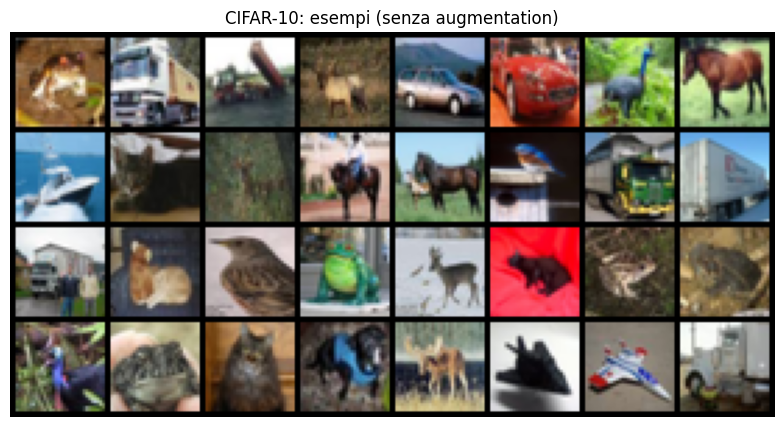

In [14]:
# Dataset "base" senza augmentation (solo ToTensor)
base_tfm = transforms.ToTensor()

train_base = datasets.CIFAR10(root="./data", train=True, download=True, transform=base_tfm)
test_base  = datasets.CIFAR10(root="./data", train=False, download=True, transform=base_tfm)

# Mostriamo 32 immagini
imgs = torch.stack([train_base[i][0] for i in range(32)])  # [32,3,32,32]
show_images(imgs, nrow=8, title="CIFAR-10: esempi (senza augmentation)")

## 3) Data augmentation

Creare **variazioni realistiche** delle immagini durante il training.

Esempi tipici:
- flip orizzontale
- crop casuale + padding
- piccole rotazioni
- variazioni di colore/contrasto (color jitter)

Obiettivo: far sì che la rete impari **invarianti** utili (es. un cane resta un cane anche se è un po' spostato o più scuro).

### 3.1 Helper: applicare la stessa augmentation più volte e visualizzarla

In [15]:
import random

def apply_aug_many_times(img, aug, rows=2, cols=4, title=None):
    """Applica la stessa augmentation più volte alla stessa immagine e mostra il risultato."""
    out = []
    for _ in range(rows * cols):
        x = aug(img)                 # tensor [C,H,W] se l'aug termina con ToTensor
        out.append(x)
    batch = torch.stack(out)
    show_images(batch, nrow=cols, title=title)

## 4) Augmentation “classiche”


Label: 6 | size: (32, 32)


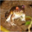

In [16]:
# Prendiamo una singola immagine in PIL (senza trasformazioni)
train = datasets.CIFAR10(root="./data", train=True, download=False, transform=None)
img, label = train[0]
print("Label:", label, "| size:", img.size)
img

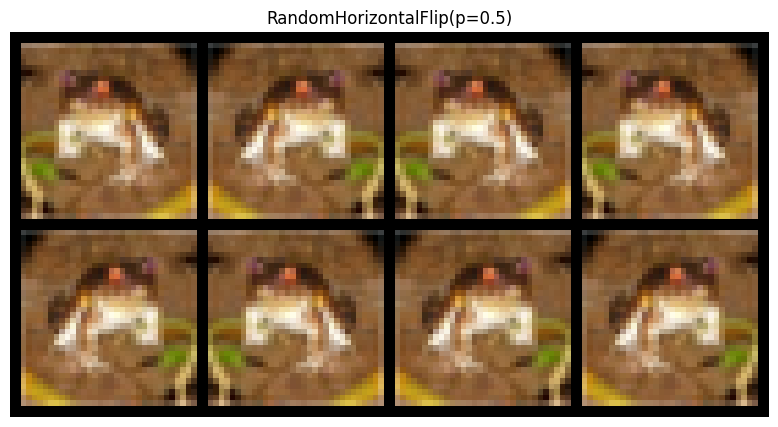

In [17]:
# 4.1 Flip orizzontale casuale
aug_flip = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])
apply_aug_many_times(img, aug_flip, title="RandomHorizontalFlip(p=0.5)")

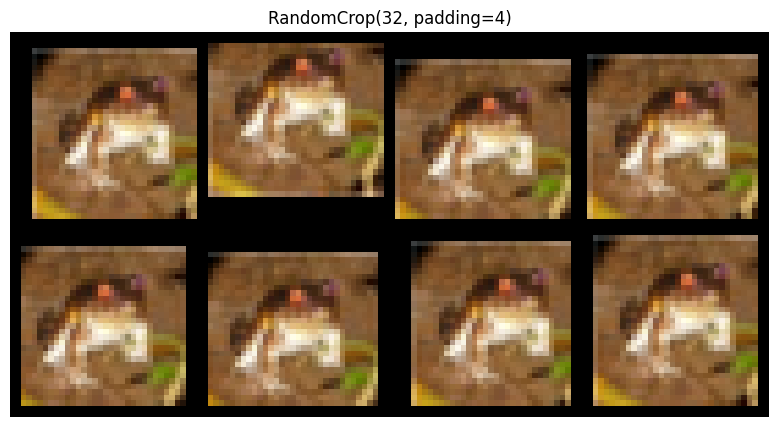

In [18]:
# 4.2 Crop casuale con padding (molto usata su CIFAR-10)
aug_crop = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor()
])
apply_aug_many_times(img, aug_crop, title="RandomCrop(32, padding=4)")

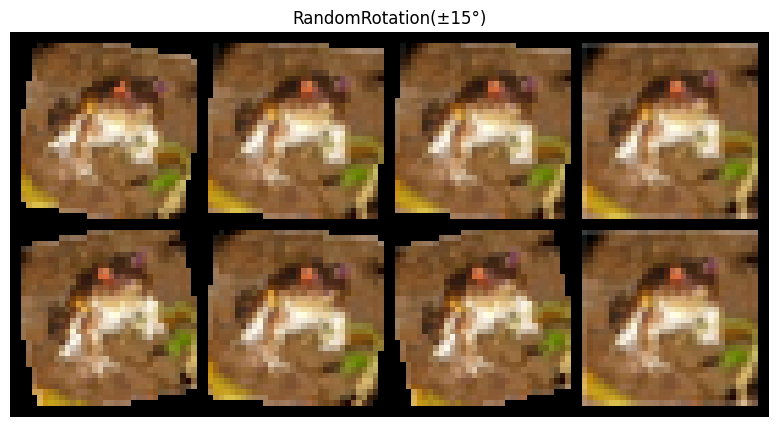

In [19]:
# 4.3 Piccola rotazione
aug_rot = transforms.Compose([
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor()
])
apply_aug_many_times(img, aug_rot, title="RandomRotation(±15°)")

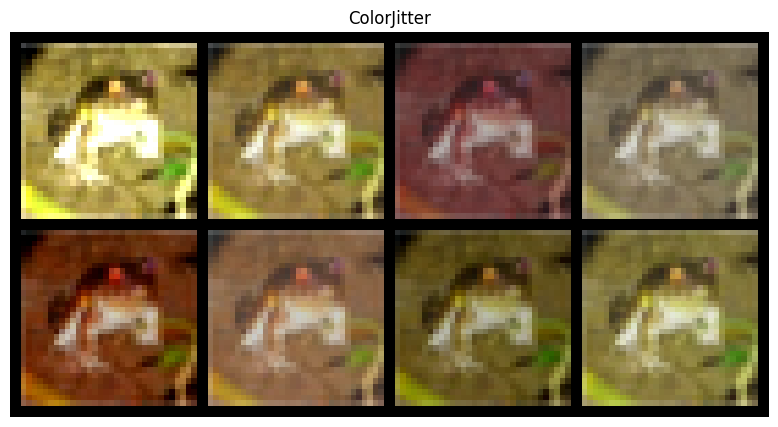

In [20]:
# 4.4 Variazioni di colore (color jitter)
aug_color = transforms.Compose([
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
    transforms.ToTensor()
])
apply_aug_many_times(img, aug_color, title="ColorJitter")

## 5) Pipeline train vs test

- **train**: augmentation + normalizzazione
- **test**: solo normalizzazione (niente random!)
 

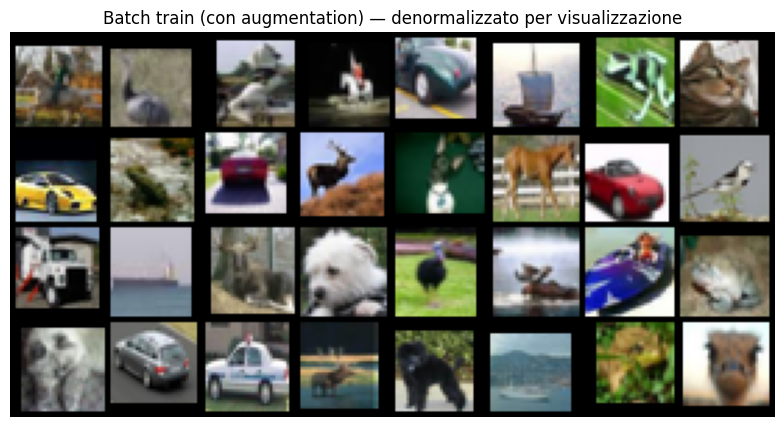

In [21]:
# Mean/std spesso usate su CIFAR-10
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2470, 0.2435, 0.2616)

train_tfm_aug = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)
])

test_tfm = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)
])

batch_size = 256
num_workers = 2  # aumenta se hai CPU potente

train_ds_aug = datasets.CIFAR10("./data", train=True, download=False, transform=train_tfm_aug)
test_ds      = datasets.CIFAR10("./data", train=False, download=False, transform=test_tfm)

train_loader_aug = DataLoader(train_ds_aug, batch_size=batch_size, shuffle=True, num_workers=num_workers)
test_loader      = DataLoader(test_ds,      batch_size=batch_size, shuffle=False, num_workers=num_workers)

# Visualizziamo un batch "augmented" (ATTENZIONE: è normalizzato, quindi per vederlo bene lo denormalizziamo)
def denormalize(x, mean=CIFAR10_MEAN, std=CIFAR10_STD):
    mean = torch.tensor(mean).view(1,3,1,1)
    std  = torch.tensor(std).view(1,3,1,1)
    return x * std + mean

X, y = next(iter(train_loader_aug))
show_images(denormalize(X[:32]), nrow=8, title="Batch train (con augmentation) — denormalizzato per visualizzazione")

## 6)  CNN minimal e confronto training con e senza augmentation

- conv → ReLU → maxpool
- conv → ReLU → maxpool
- classificatore fully-connected

Due esperimenti:
1) training **senza augmentation**
2) training **con augmentation**

In [ ]:
class SmallCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),   # 32x32 -> 16x16
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),   # 16x16 -> 8x8
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*8*8, 128), nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

@torch.no_grad()
def accuracy(model, loader):
    model.eval()
    correct, total = 0, 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        pred = model(X).argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.size(0)
    return correct / total

def train_model(model, train_loader, test_loader, epochs=5, lr=0.01):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optim = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses, train_accs, test_accs = [], [], []

    for ep in range(1, epochs+1):
        model.train()
        running_loss = 0.0
        correct, total = 0, 0

        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            loss = criterion(logits, y)

            optim.zero_grad()
            loss.backward()
            optim.step()

            running_loss += loss.item() * X.size(0)
            pred = logits.argmax(dim=1)
            correct += (pred == y).sum().item()
            total += y.size(0)

        ep_loss = running_loss / total
        ep_train_acc = correct / total
        ep_test_acc = accuracy(model, test_loader)

        train_losses.append(ep_loss)
        train_accs.append(ep_train_acc)
        test_accs.append(ep_test_acc)

        print(f"Epoca {ep:02d} | loss {ep_loss:.4f} | train acc {ep_train_acc:.4f} | test acc {ep_test_acc:.4f}")

    # Plot
    xs = range(1, epochs+1)
    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.plot(xs, train_losses, marker='o')
    plt.title("Loss di training")
    plt.xlabel("Epoca"); plt.ylabel("Loss"); plt.grid(True)

    plt.subplot(1,2,2)
    plt.plot(xs, train_accs, marker='o', label="Train")
    plt.plot(xs, test_accs,  marker='s', label="Test")
    plt.title("Accuracy")
    plt.xlabel("Epoca"); plt.ylabel("Accuracy"); plt.grid(True); plt.legend()

    plt.tight_layout()
    plt.show()


## 7) Esperimento A — training **senza** augmentation

Epoca 01 | loss 1.4551 | train acc 0.4813 | test acc 0.5832
Epoca 02 | loss 1.0783 | train acc 0.6213 | test acc 0.6548
Epoca 03 | loss 0.9363 | train acc 0.6756 | test acc 0.6719
Epoca 04 | loss 0.8467 | train acc 0.7085 | test acc 0.6950
Epoca 05 | loss 0.7622 | train acc 0.7353 | test acc 0.7054
Epoca 06 | loss 0.6967 | train acc 0.7599 | test acc 0.7130
Epoca 07 | loss 0.6372 | train acc 0.7803 | test acc 0.7224
Epoca 08 | loss 0.5738 | train acc 0.8026 | test acc 0.7229
Epoca 09 | loss 0.5184 | train acc 0.8217 | test acc 0.7253
Epoca 10 | loss 0.4605 | train acc 0.8416 | test acc 0.7247
Epoca 11 | loss 0.4051 | train acc 0.8609 | test acc 0.7268
Epoca 12 | loss 0.3516 | train acc 0.8812 | test acc 0.7215
Epoca 13 | loss 0.3006 | train acc 0.8981 | test acc 0.7293
Epoca 14 | loss 0.2546 | train acc 0.9151 | test acc 0.7185
Epoca 15 | loss 0.2142 | train acc 0.9305 | test acc 0.7193
Epoca 16 | loss 0.1856 | train acc 0.9393 | test acc 0.7232
Epoca 17 | loss 0.1379 | train acc 0.957

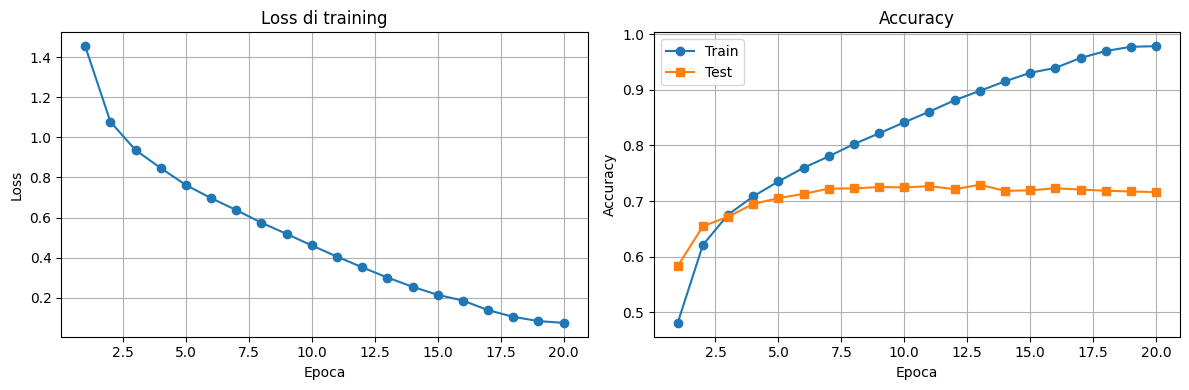

In [27]:
# Loader senza augmentation (solo Normalize)
train_ds_noaug = datasets.CIFAR10("./data", train=True, download=False, transform=test_tfm)
train_loader_noaug = DataLoader(train_ds_noaug, batch_size=batch_size, shuffle=True, num_workers=num_workers)

model = SmallCNN().to(device)
train_model(model, train_loader_noaug, test_loader, epochs=20, lr=0.001)

## 8) Esperimento B — training **con** augmentation

Epoca 01 | loss 1.6361 | train acc 0.4069 | test acc 0.5433
Epoca 02 | loss 1.2941 | train acc 0.5399 | test acc 0.6145
Epoca 03 | loss 1.1633 | train acc 0.5890 | test acc 0.6507
Epoca 04 | loss 1.0826 | train acc 0.6149 | test acc 0.6670
Epoca 05 | loss 1.0249 | train acc 0.6380 | test acc 0.6624
Epoca 06 | loss 0.9774 | train acc 0.6558 | test acc 0.6865
Epoca 07 | loss 0.9340 | train acc 0.6721 | test acc 0.6981
Epoca 08 | loss 0.9082 | train acc 0.6816 | test acc 0.7180
Epoca 09 | loss 0.8787 | train acc 0.6921 | test acc 0.7220
Epoca 10 | loss 0.8565 | train acc 0.6983 | test acc 0.7204
Epoca 11 | loss 0.8326 | train acc 0.7096 | test acc 0.7238
Epoca 12 | loss 0.8115 | train acc 0.7157 | test acc 0.7353
Epoca 13 | loss 0.7896 | train acc 0.7226 | test acc 0.7418
Epoca 14 | loss 0.7767 | train acc 0.7283 | test acc 0.7428
Epoca 15 | loss 0.7622 | train acc 0.7331 | test acc 0.7551
Epoca 16 | loss 0.7471 | train acc 0.7398 | test acc 0.7594
Epoca 17 | loss 0.7331 | train acc 0.746

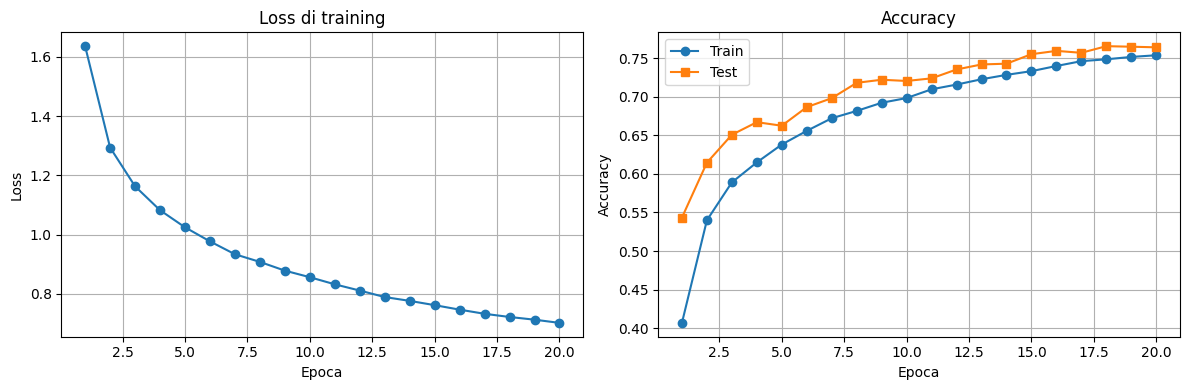

In [28]:
model = SmallCNN().to(device)
train_model(model, train_loader_aug, test_loader, epochs=20, lr=0.001)